In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)



In [2]:
df = pd.read_csv("../data/processed/penn_state_processed_combined_stats.csv")
df.head(10)

,Date,Opponent,Location,Result,Box Score Link,WMT Game ID,PSU Goals,PSU Shots on Goal,PSU Total Shot Attempts,PSU Faceoffs Won,...,Faceoff Differential,PSU Save %,Opponent Save %,Home Game,Venue_Type,Total Goals,Total Penalty Minutes,PSU Shooting %,Opponent Shooting %,Season
0,Friday Oct 3,Arizona State,"Tempe, Ariz. / Mullett Arena",W Win 6-3,https://gopsusports.com/boxscore/17959,6440318,6,47,69,32,...,-16.88,0.921,0.872,0,Away,9,34,12.765957,7.894737,2025-2026
1,Saturday Oct 4,Arizona State,"Tempe, Ariz. / Mullett Arena",W Win 4-2,https://gopsusports.com/boxscore/17960,6440319,4,46,76,29,...,-18.30,0.957,0.913,0,Away,6,22,8.695652,4.255319,2025-2026
2,Thursday Oct 9,Clarkson,"University Park, Pa. / Pegula Ice Arena",L Loss 4-6,https://gopsusports.com/boxscore/17961,6440320,4,40,75,37,...,10.44,0.769,0.900,1,Home,10,28,10.000000,23.076923,2025-2026
3,Friday Oct 10,Clarkson,"University Park, Pa. / Pegula Ice Arena",W Win 5-2,https://gopsusports.com/boxscore/17962,6440321,5,31,57,30,...,11.12,0.913,0.839,1,Home,7,152,16.129032,8.695652,2025-2026
4,Friday Oct 17,LIU,"University Park, Pa. / Pegula Ice Arena",W Win 5-4,https://gopsusports.com/boxscore/17963,6424375,5,41,66,37,...,5.72,0.889,0.878,1,Home,9,35,12.195122,11.111111,2025-2026
5,Saturday Oct 18,LIU,"University Park, Pa. / Pegula Ice Arena",W Win 3-0,https://gopsusports.com/boxscore/17964,6424376,3,38,72,38,...,20.64,1.000,0.921,1,Home,3,101,7.894737,0.000000,2025-2026
6,Friday Oct 24,Stonehill,"University Park, Pa. / Pegula Ice Arena",W Win 3-2,https://gopsusports.com/boxscore/17965,6440323,3,36,63,38,...,35.72,0.938,0.917,1,Home,5,18,8.333333,6.250000,2025-2026
7,Saturday Oct 25,Stonehill,"University Park, Pa. / Pegula Ice Arena",W Win 4-2,https://gopsusports.com/boxscore/17966,6440324,4,32,60,36,...,10.76,0.929,0.875,1,Home,6,24,12.500000,7.142857,2025-2026
8,Thursday Oct 30,Ohio State,"Columbus, Ohio / Value City Arena",W Win 3-2,https://gopsusports.com/boxscore/18294,6440325,3,37,64,39,...,1.30,0.933,0.919,0,Away,5,34,8.108108,6.666667,2025-2026
9,Friday Nov 7,Michigan State,"East Lansing, Mich. / Munn Ice Arena",L Loss 1-2,https://gopsusports.com/boxscore/18296,6440327,1,25,44,32,...,8.48,0.938,0.960,0,Away,3,16,4.000000,6.250000,2025-2026


In [3]:
features = [
    "PSU Shots on Goal", 
    "Opponent Shots on Goal", 
    "Shot Differential",
    "PSU Faceoff %",
    "Opponent Faceoff %",
    "Faceoff Differential",
    "PSU Blocks",
    "Opponent Blocks",
    "PSU Penalty Minutes",
    "Opponent Penalty Minutes"
]



In [4]:
X = df[features]
y = df["Win"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Training games:", len(X_train))
print("Testing games:", len(X_test))

Training games: 54
Testing games: 14


In [5]:
rf_param_grid = {
    "n_estimators" : [100, 200, 300],
    "max_depth" : [3,5,7,None], 
    "min_samples_split" : [2, 5, 10], 
    "min_samples_leaf" : [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

rf_grid = GridSearchCV(
    estimator=rf, 
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1", 
    n_jobs=-1
)

rf_grid.fit(X,y)


print("Best Parameters:")
print(rf_grid.best_params_)

print()

print("Best Cross-Validation F1:")
print(rf_grid.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation F1:
1.0


In [6]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [7]:
predictions = model.predict(X_test)

In [8]:
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.3f}")
print(confusion_matrix(
    y_test,
    predictions
))
print(classification_report(
    y_test,
    predictions
))

Accuracy: 0.429
[[1 5]
 [3 5]]
              precision    recall  f1-score   support

           0       0.25      0.17      0.20         6
           1       0.50      0.62      0.56         8

    accuracy                           0.43        14
   macro avg       0.38      0.40      0.38        14
weighted avg       0.39      0.43      0.40        14



In [9]:
feature_importance = pd.DataFrame({"Feature":X.columns, "Coefficient":model.coef_[0]})
feature_importance["Absolute Coefficient"] = (feature_importance["Coefficient"].abs())
feature_importance = feature_importance.sort_values(by = "Absolute Coefficient", ascending = False)
feature_importance

,Feature,Coefficient,Absolute Coefficient
6,PSU Blocks,0.192706,0.192706
0,PSU Shots on Goal,0.161301,0.161301
2,Shot Differential,0.116949,0.116949
4,Opponent Faceoff %,-0.106474,0.106474
9,Opponent Penalty Minutes,0.105114,0.105114
8,PSU Penalty Minutes,-0.104933,0.104933
7,Opponent Blocks,-0.094382,0.094382
5,Faceoff Differential,0.055443,0.055443
3,PSU Faceoff %,-0.051031,0.051031
1,Opponent Shots on Goal,0.044351,0.044351


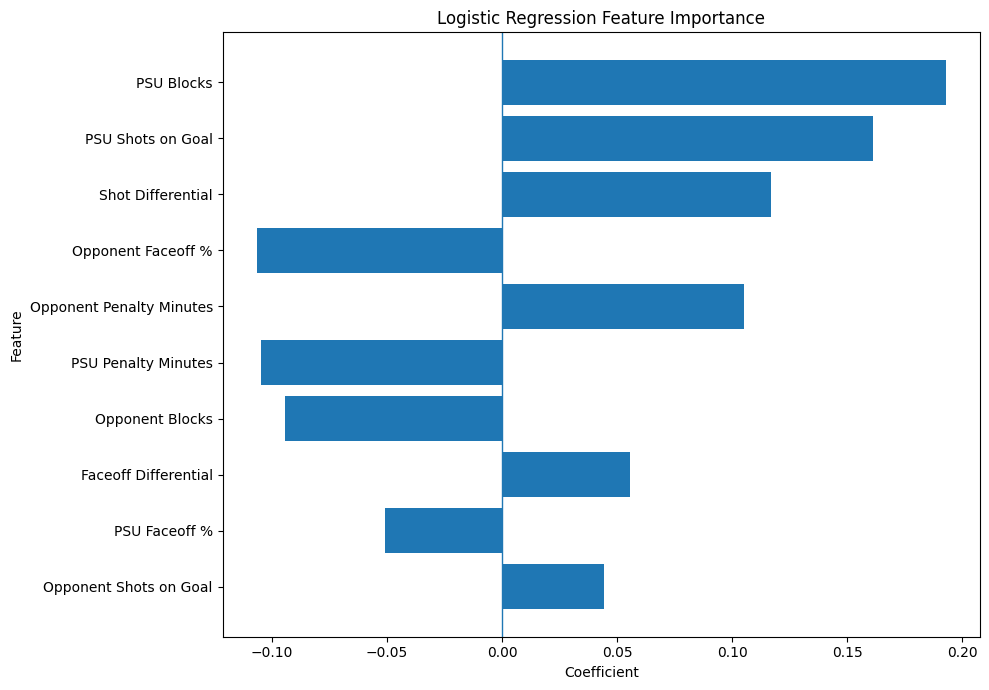

In [10]:

plt.figure(figsize=(10,7))

plt.barh(feature_importance["Feature"],feature_importance["Coefficient"])
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.axvline(0, linewidth=1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

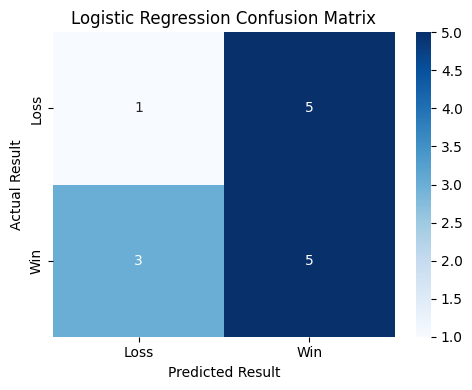

In [11]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")

plt.tight_layout()
plt.show()

In [12]:
models = {
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Decision Tree":DecisionTreeClassifier(random_state=42, max_depth=4),
    "Random Forest":RandomForestClassifier(n_estimators=200, random_state=42, max_depth=5),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42)
}

model_results = []
trained_models = {}

for model_name, current_model in models.items():

    current_model.fit(X_train, y_train)

    current_predictions = current_model.predict(X_test)
    
    current_accuracy = accuracy_score(y_test, current_predictions)

    current_report = classification_report(y_test, current_predictions, output_dict=True, zero_division=0)

    model_results.append({
        "Model" : model_name,
        "Accuracy" : current_accuracy,
        "Precision" : current_report["weighted avg"]["precision"],
        "Recall": current_report["weighted avg"]["recall"],
        "F1 Score": current_report["weighted avg"]["f1-score"]
    })

    trained_models[model_name] = current_model 

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(by=["Accuracy", "F1 Score", "Precision", "Recall"], ascending=False)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1 Score
3    Gradient Boosting  1.000000   1.000000  1.000000  1.000000
2        Random Forest  0.857143   0.885714  0.857143  0.850794
1        Decision Tree  0.714286   0.721429  0.714286  0.701587
0  Logistic Regression  0.428571   0.392857  0.428571  0.403175


                 Model  Mean Accuracy  Accuracy Std  Mean Precision  \
2        Random Forest       0.984615      0.030769        0.977778   
3    Gradient Boosting       0.969231      0.061538        1.000000   
1        Decision Tree       0.927473      0.063925        0.897778   
0  Logistic Regression       0.735165      0.035845        0.761111   

   Mean Recall  Mean F1 Score    F1 Std  
2         1.00       0.988235  0.023529  
3         0.95       0.971429  0.057143  
1         1.00       0.943791  0.049708  
0         0.80       0.779412  0.036022  


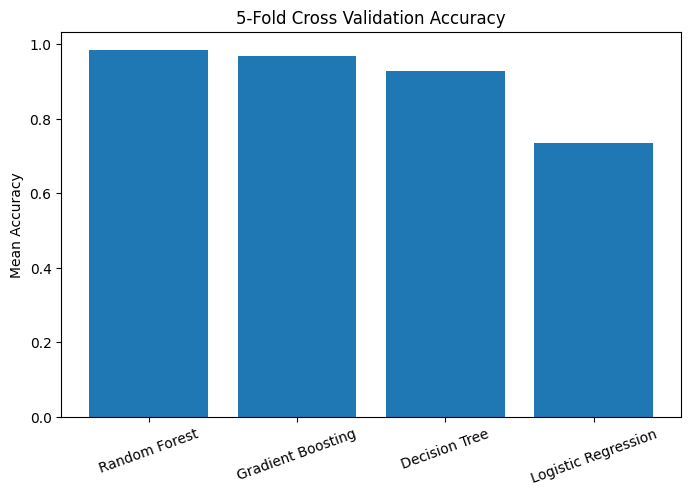

In [13]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, current_model in models.items():

    scores = cross_validate(
        current_model, X, y, cv=skf, scoring={"accuracy":"accuracy", "precision":"precision", "recall":"recall", "f1":"f1"}
    )

    cv_results.append({
        "Model":model_name,
        "Mean Accuracy":scores["test_accuracy"].mean(), 
        "Accuracy Std": scores["test_accuracy"].std(),
        "Mean Precision": scores["test_precision"].mean(),
        "Mean Recall": scores["test_recall"].mean(),
        "Mean F1 Score": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),
    })

cv_results = pd.DataFrame(cv_results)
cv_results = cv_results.sort_values(by="Mean Accuracy", ascending=False) 
print(cv_results)
cv_results.to_csv(
    "../reports/cross_validation_results.csv",
    index=False
)

plt.figure(figsize=(8,5))

plt.bar(
    cv_results["Model"],
    cv_results["Mean Accuracy"]
)

plt.ylabel("Mean Accuracy")
plt.title("5-Fold Cross Validation Accuracy")

plt.xticks(rotation=20)

plt.show()

In [14]:
importance_model = trained_models["Random Forest"].feature_importances_
model_feature_importance = pd.DataFrame({
    "Feature": X.columns, 
    "Importance":importance_model
})
model_feature_importance = model_feature_importance.sort_values(by="Importance", ascending=False)
model_feature_importance = model_feature_importance.reset_index(drop=True)
model_feature_importance

model_feature_importance.to_csv(
    "../reports/model_feature_importance.csv",
    index=False
)

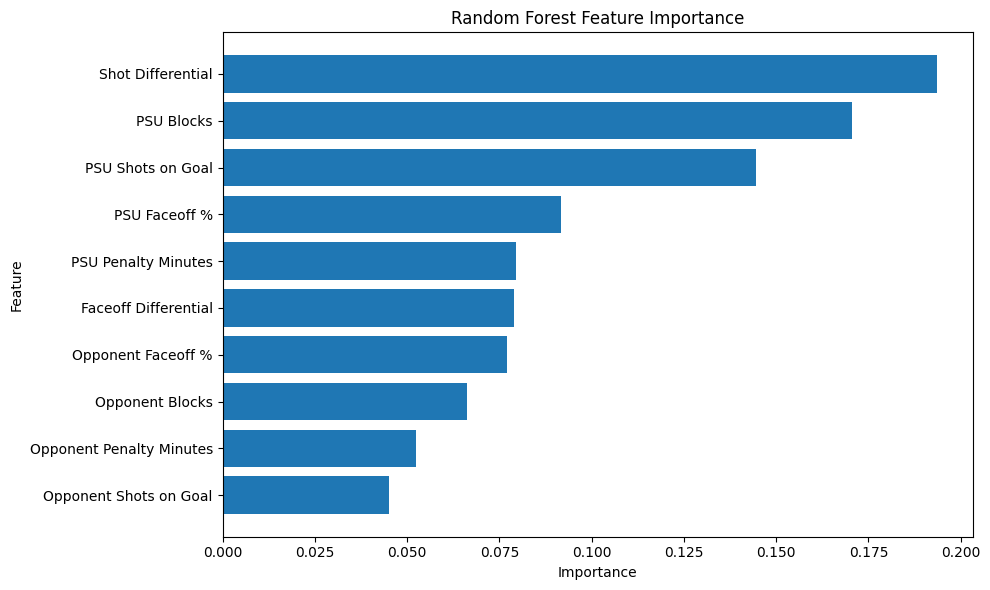

In [15]:
plt.figure(figsize=(10, 6))
plt.barh(
    model_feature_importance["Feature"],
    model_feature_importance["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [16]:
results_df = pd.DataFrame(model_results)
results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.428571,0.392857,0.428571,0.403175
1,Decision Tree,0.714286,0.721429,0.714286,0.701587
2,Random Forest,0.857143,0.885714,0.857143,0.850794
3,Gradient Boosting,1.000000,1.000000,1.000000,1.000000


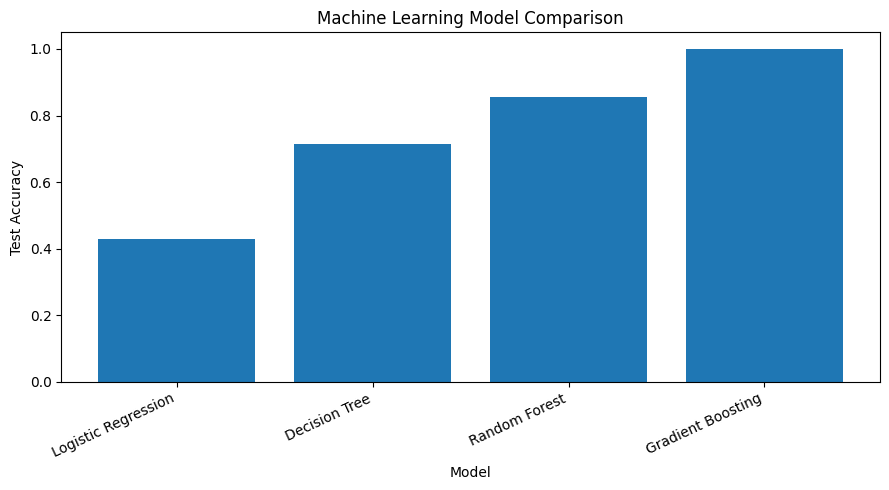

In [17]:
plt.figure(figsize=(9,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.05)

plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

In [18]:
best_model_name = results_df.loc[0, "Model"]

best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print(
    "Best F1 score:",
    round(results_df.loc[0, "F1 Score"], 3)
)

Best model: Logistic Regression
Best F1 score: 0.403


In [19]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/best_hockey_model.joblib"
)

joblib.dump(
    features,
    "../models/model_features.joblib"
)

print("Model and feature list saved successfully.")

Model and feature list saved successfully.
